In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [26]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

aum_data = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

monthly_sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")    

category_data=pd.read_csv("../data/raw/05_category_inflows.csv")    

age_counts=pd.read_csv("../data/raw/06_industry_folio_count.csv")               

investors = pd.read_csv("../data/raw/08_investor_transactions.csv")

scheme_perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

folio_data=pd.read_csv("../data/raw/09_portfolio_holdings.csv")


In [27]:
print(nav.shape)
print(nav.head())

(46000, 3)
   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [41]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

fig = px.line(
    nav_history,
    x='date',
    y='nav',
    color='amfi_code',
    title='NAV Trend Analysis (2022-2026)'
)

fig.show()

NameError: name 'px' is not defined

<Axes: xlabel='date', ylabel='aum_lakh_crore'>

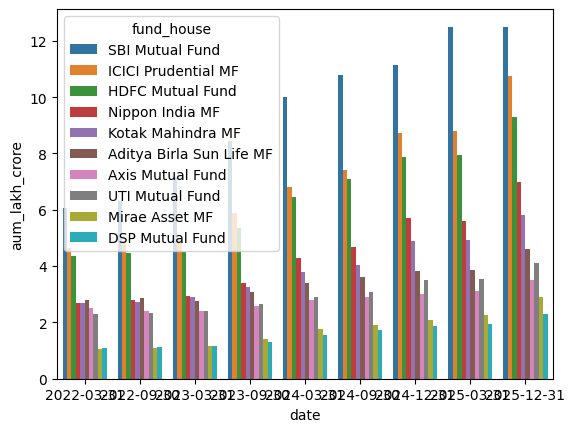

In [29]:
sns.barplot(
    data=aum_data,
    x='date',
    y='aum_lakh_crore',
    hue='fund_house'
)


['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


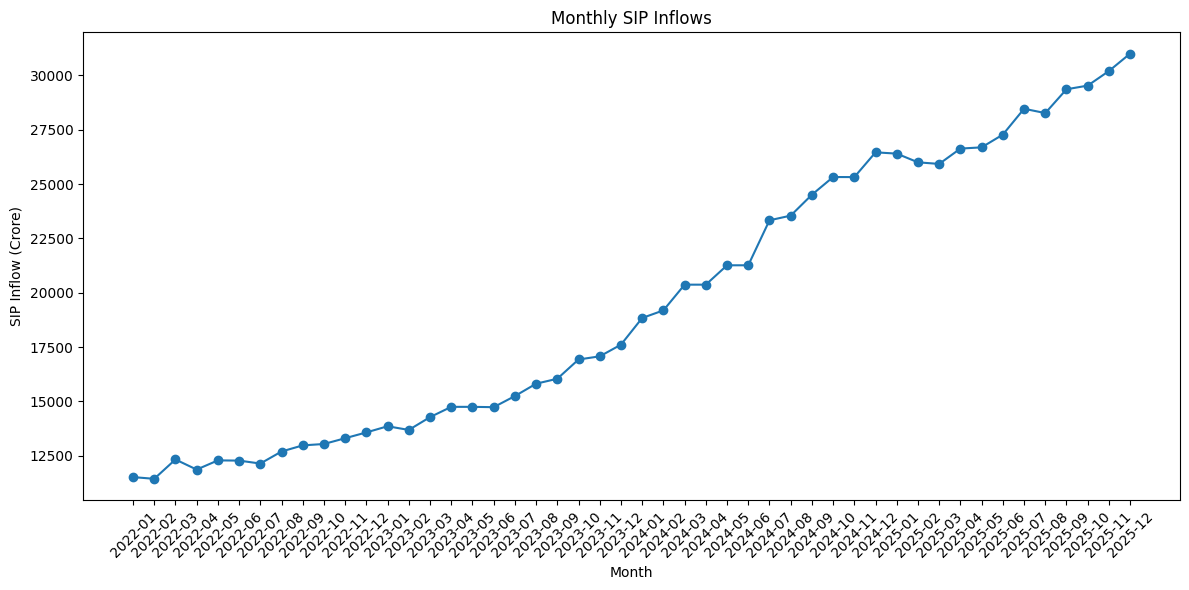

In [30]:

transactions=pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
transactions.columns=transactions.columns.str.strip()
print(transactions.columns.tolist())
plt.figure(figsize=(12,6))
plt.plot(transactions['month'], transactions['sip_inflow_crore'], marker='o')
plt.title('Monthly SIP Inflows')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

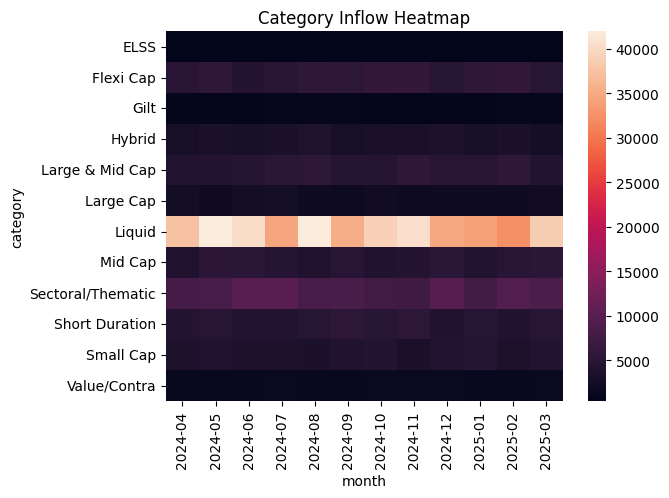

In [31]:
pivot = category_data.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

sns.heatmap(pivot)

plt.title("Category Inflow Heatmap")
plt.show()

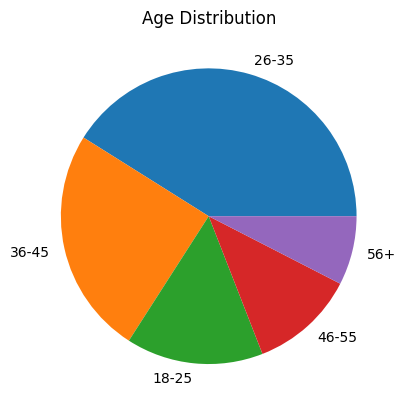

In [34]:
age_counts = investors['age_group'].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index
)

plt.title("Age Distribution")
plt.show()

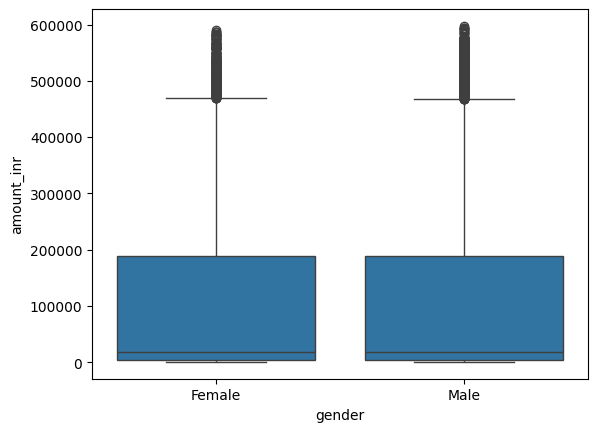

In [32]:
sns.boxplot(
    x='gender',
    y='amount_inr',
    data=investors
)

plt.show()

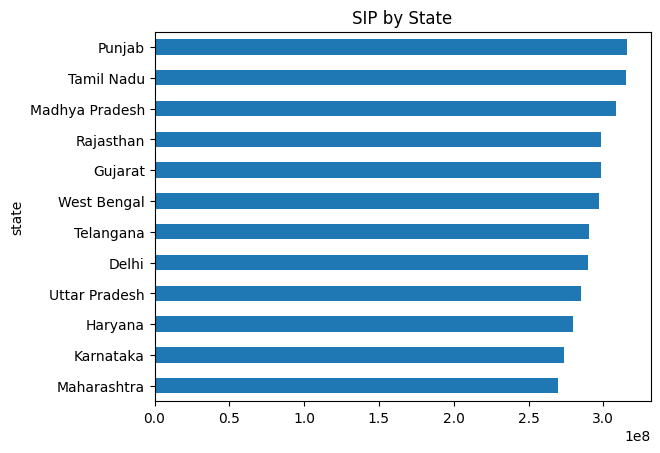

In [39]:
state_data = (
    investors.groupby('state')['amount_inr']
    .sum()
    .sort_values()
)

state_data.plot(kind='barh')

plt.title("SIP by State")
plt.show()

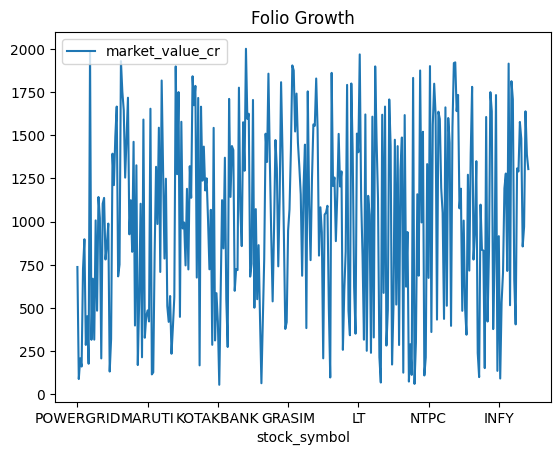

In [48]:
folio_data.plot(
    x='stock_symbol',
    y='market_value_cr'
)

plt.title("Folio Growth")
plt.show()

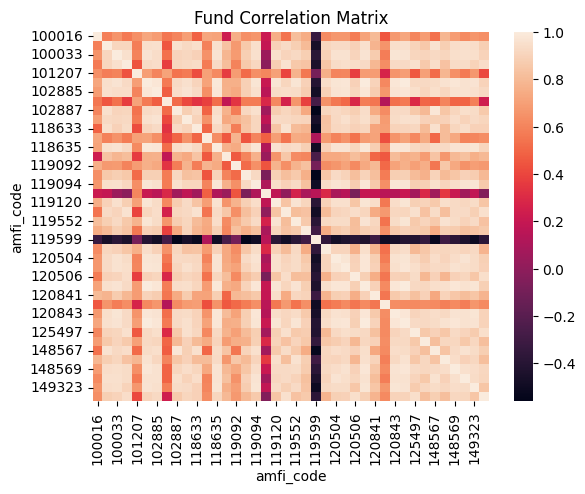

In [49]:
returns = nav_history.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

corr = returns.corr()

sns.heatmap(corr)

plt.title("Fund Correlation Matrix")
plt.show()


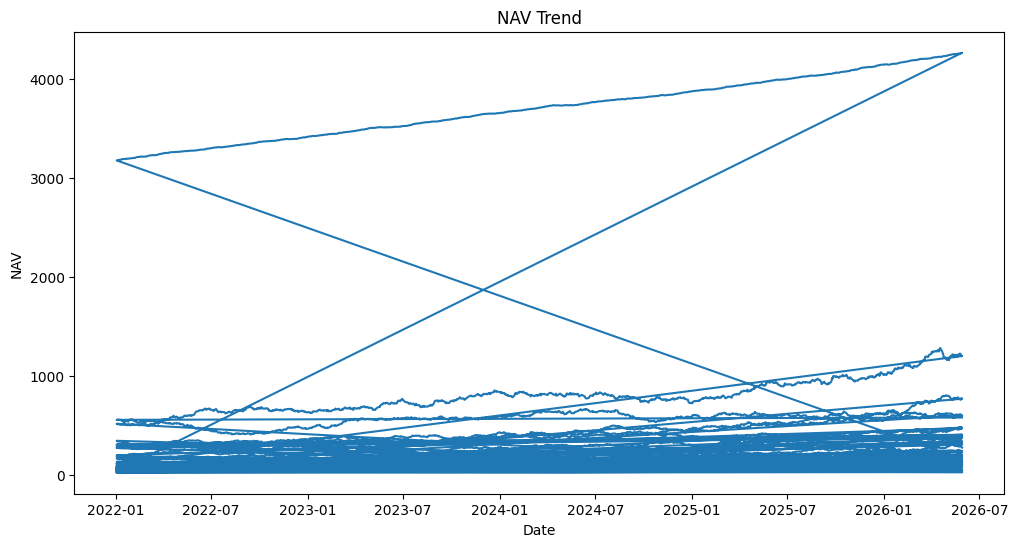

In [33]:

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

plt.figure(figsize=(12,6))
plt.plot(nav['date'], nav['nav'])

plt.title("NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")


plt.savefig("../reports/charts/nav_trend.png")
plt.show()


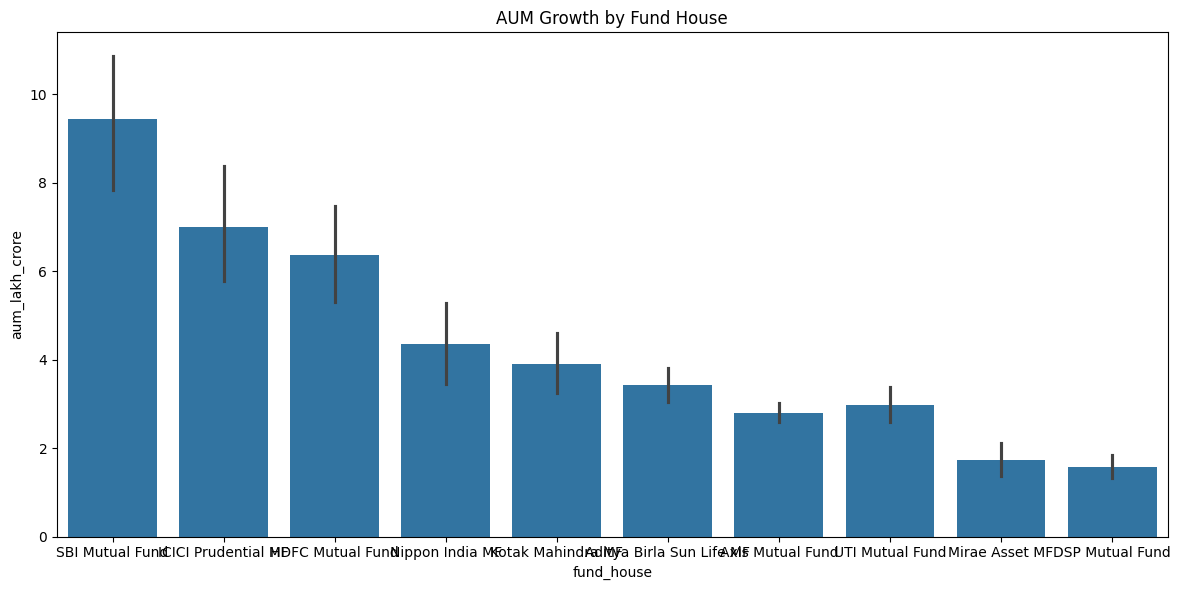

In [35]:


plt.figure(figsize=(12,6))
sns.barplot(
    data=aum_data,
    x='fund_house',
    y='aum_lakh_crore'
)

plt.title("AUM Growth by Fund House")
plt.tight_layout()
plt.savefig("../reports/charts/aum_growth.png")
plt.show()

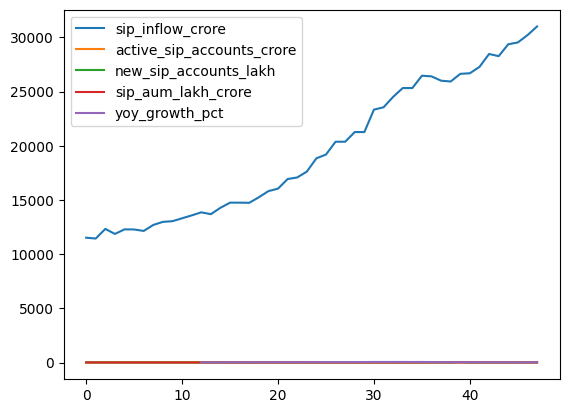

In [36]:
monthly_sip.plot()

plt.savefig(
    "../reports/charts/sip_trend.png"
)

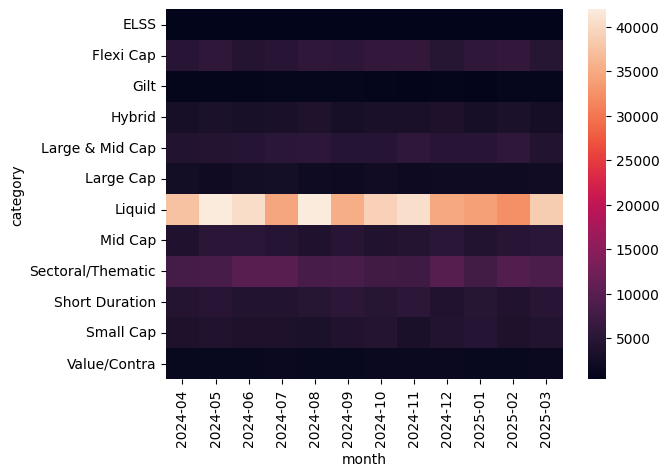

In [37]:
sns.heatmap(pivot)

plt.savefig(
    "../reports/charts/category_heatmap.png"
)

ValueError: could not convert string to float: '2022-01'

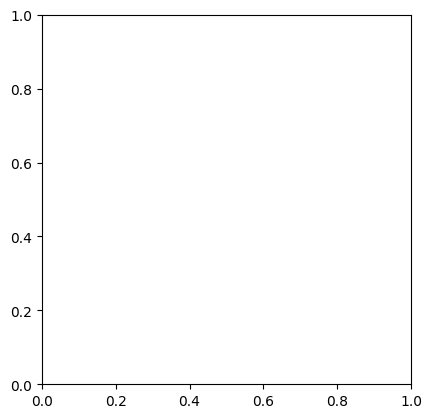

In [39]:
plt.pie(age_counts)
plt.title("Age Distribution")
plt.savefig(
    "../reports/charts/demographics.png"
)
plt.show()

In [40]:
state_data.plot(kind='barh')

plt.savefig(
    "../reports/charts/geography.png"
)


NameError: name 'state_data' is not defined

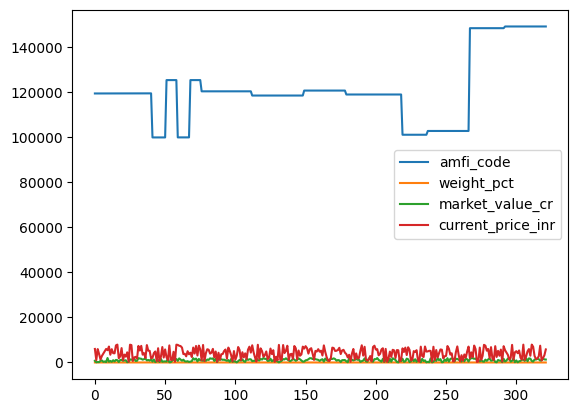

In [76]:
folio_data.plot()

plt.savefig(
    "../reports/charts/folio_growth.png"
)

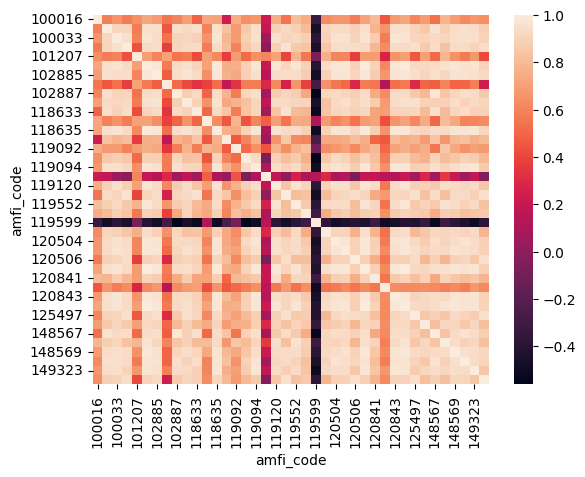

In [75]:
sns.heatmap(corr)

plt.savefig(
    "../reports/charts/correlation_matrix.png"
)

In [11]:
holdings=pd.read_csv("../data/raw/09_portfolio_holdings.csv")
print(holdings.columns)
print(holdings.head())

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


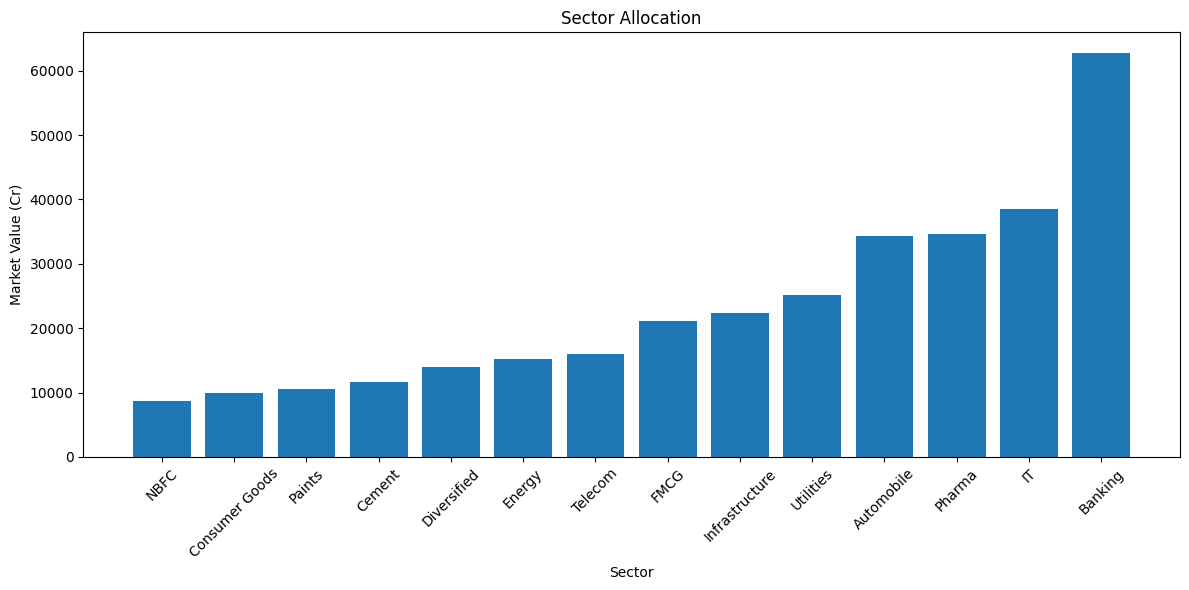

In [12]:
sector_allocation = holdings.groupby('sector')['market_value_cr'].sum().sort_values()

plt.figure(figsize=(12,6))
plt.bar(sector_allocation.index, sector_allocation.values)
plt.title("Sector Allocation")
plt.xlabel("Sector")
plt.ylabel("Market Value (Cr)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "../reports/charts/sector_allocation.png"
)
plt.show()